# RoadWatch — YOLOv8-nano Fine-tuning on RDD2022
## Run on Google Colab (Free T4 GPU) — NO Roboflow needed
### Steps:
1. Enable GPU: Runtime → Change runtime type → **T4 GPU** → Save
2. Run cells **1 through 9** in order (skip nothing)
3. Cell 9 downloads `roadwatch_best.pt` to your computer
4. Place that file in `backend/ml/roadwatch_best.pt`

**Total time: ~60-90 minutes on Colab T4**

In [1]:
# Cell 1 — Install dependencies (no Roboflow needed)
!pip install ultralytics gdown -q
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected! Go to Runtime → Change runtime type → T4 GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.2 MB/s eta 0:00:00
PyTorch: 2.11.0+cpu
CUDA available: False


In [2]:
# NEW CELL — Replace everything from Cell 4 onwards
# This dataset has YOLO-format labels already — no XML conversion needed
!kaggle datasets download -d sreekaraditya/rdd2022-yolo-crackscan-v2 \
    -p /content/rdd2022_yolo_raw/ --unzip

from pathlib import Path
import shutil, yaml

raw = Path('/content/rdd2022_yolo_raw')

# Check structure
for split in ['train', 'valid', 'test']:
    imgs = list((raw / split / 'images').glob('*.jpg')) if (raw / split / 'images').exists() else []
    lbls = list((raw / split / 'labels').glob('*.txt')) if (raw / split / 'labels').exists() else []
    print(f"{split}: {len(imgs)} images, {len(lbls)} labels")

# Check what classes the dataset uses
sample_labels = list((raw / 'train' / 'labels').glob('*.txt'))[:200]
class_ids = set()
for lf in sample_labels:
    for line in lf.read_text().strip().splitlines():
        if line.strip():
            class_ids.add(int(line.split()[0]))
print(f"Class IDs found in labels: {sorted(class_ids)}")

# Read existing data.yaml to see original class names
yaml_candidates = list(raw.glob('*.yaml')) + list(raw.glob('**/*.yaml'))
for yf in yaml_candidates:
    print(f"\n{yf}:")
    print(yf.read_text())

Dataset URL: https://www.kaggle.com/datasets/sreekaraditya/rdd2022-yolo-crackscan-v2
License(s): CC-BY-SA-4.0
 11% 1.37G/12.3G [00:17<02:23, 82.2MB/s]
User cancelled operation
train: 0 images, 0 labels
valid: 0 images, 0 labels
test: 0 images, 0 labels
Class IDs found in labels: []


In [2]:
# Cell A — Remap class IDs and create val split from train
import shutil, random
from pathlib import Path

raw = Path('/content/rdd2022_yolo_raw')
out = Path('/content/rdd2022_yolo')

# RDD2022 → RoadWatch mapping:
# 0 Longitudinal → 1 Surface Crack
# 1 Transverse   → 1 Surface Crack
# 2 Alligator    → 1 Surface Crack
# 3 Pothole      → 0 Pothole
REMAP = {'0': '1', '1': '1', '2': '1', '3': '0'}

def remap_label_file(src, dst):
    lines = src.read_text().strip().splitlines()
    new_lines = []
    for line in lines:
        if not line.strip():
            continue
        parts = line.split()
        parts[0] = REMAP.get(parts[0], '1')
        new_lines.append(' '.join(parts))
    dst.write_text('\n'.join(new_lines))

# Get all train samples and carve out 10% as val
all_train_imgs = sorted((raw / 'train' / 'images').glob('*.jpg'))
random.seed(42)
random.shuffle(all_train_imgs)
n_val = int(len(all_train_imgs) * 0.10)
val_imgs   = all_train_imgs[:n_val]
train_imgs = all_train_imgs[n_val:]
test_imgs  = sorted((raw / 'test' / 'images').glob('*.jpg'))

splits = {
    'train': train_imgs,
    'valid': val_imgs,
    'test':  test_imgs,
}

for split_name, img_list in splits.items():
    (out / split_name / 'images').mkdir(parents=True, exist_ok=True)
    (out / split_name / 'labels').mkdir(parents=True, exist_ok=True)
    for img_path in img_list:
        shutil.copy2(img_path, out / split_name / 'images' / img_path.name)
        src_label = raw / ('train' if split_name != 'test' else 'test') / 'labels' / (img_path.stem + '.txt')
        dst_label = out / split_name / 'labels' / (img_path.stem + '.txt')
        if src_label.exists():
            remap_label_file(src_label, dst_label)
    print(f"{split_name}: {len(img_list)} images")

print("Done!")

train: 29366 images
valid: 3262 images
test: 9035 images
Done!


In [5]:
# Cell A2 — Trim dataset to 8000 train + 1000 val (much faster, still good results)
import random, shutil
from pathlib import Path

out = Path('/content/rdd2022_yolo')
random.seed(42)

for split, keep in [('train', 8000), ('valid', 1000)]:
    imgs = sorted((out / split / 'images').glob('*.jpg'))
    random.shuffle(imgs)
    remove = imgs[keep:]
    for img in remove:
        img.unlink()
        lbl = out / split / 'labels' / (img.stem + '.txt')
        if lbl.exists():
            lbl.unlink()
    remaining = len(list((out / split / 'images').glob('*.jpg')))
    print(f"{split}: trimmed to {remaining} images")

train: trimmed to 8000 images
valid: trimmed to 1000 images


In [6]:
# Cell B — Write RoadWatch data.yaml
import yaml

data_yaml = {
    'path': '/content/rdd2022_yolo',
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 5,
    'names': [
        'Pothole',
        'Surface Crack',
        'Missing Signage',
        'Faded Lane Marking',
        'Damaged Guardrail',
    ]
}

with open('/content/roadwatch_data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

# Verify class distribution
import collections
counts = collections.Counter()
for lf in Path('/content/rdd2022_yolo/train/labels').glob('*.txt'):
    for line in lf.read_text().strip().splitlines():
        if line.strip():
            counts[int(line.split()[0])] += 1

names = data_yaml['names']
print("Class distribution in train:")
for cls_id, count in sorted(counts.items()):
    print(f"  {names[cls_id]}: {count:,} boxes")
print("\ndata.yaml written. Ready to train.")

Class distribution in train:
  Pothole: 1,381 boxes
  Surface Crack: 10,110 boxes

data.yaml written. Ready to train.


In [ ]:
# Cell C — Fine-tune YOLOv8-nano (~60-90 min on T4)
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/roadwatch_data.yaml',
    epochs=40,
    imgsz=640,
    batch=32,
    patience=15,
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=3,
    cos_lr=True,
    degrees=10.0,
    flipud=0.0,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    name='roadwatch_nano_v2',
    project='/content/runs/train',
    exist_ok=True,
    device=0,
)
print("Training complete!")
# Cell D — Validate and download weights
from ultralytics import YOLO
from google.colab import files
import shutil, glob

best_pt = '/content/runs/train/roadwatch_nano/weights/best.pt'
model = YOLO(best_pt)

metrics = model.val(data='/content/roadwatch_data.yaml', verbose=False)
print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

# Test on 3 sample images
names = ['Pothole','Surface Crack','Missing Signage','Faded Lane Marking','Damaged Guardrail']
for img in glob.glob('/content/rdd2022_yolo/test/images/*.jpg')[:3]:
    r = model(img, conf=0.25, verbose=False)[0]
    if len(r.boxes) == 0:
        print(f"  {img.split('/')[-1]}: no detection")
        continue
    best = r.boxes.conf.argmax().item()
    cls  = int(r.boxes.cls[best])
    conf = float(r.boxes.conf[best])
    box  = r.boxes.xyxy[best].cpu().numpy()
    h, w = r.orig_shape
    ratio = ((box[2]-box[0])*(box[3]-box[1]))/(w*h)
    sev = 1 if ratio<0.01 else 2 if ratio<0.03 else 3 if ratio<0.08 else 4 if ratio<0.15 else 5
    if conf < 0.45: sev = max(1, sev-1)
    elif conf > 0.80: sev = min(5, sev+1)
    print(f"  {img.split('/')[-1]}: {names[cls]}, severity={sev}, conf={conf:.1%}")

# Download
shutil.copy(best_pt, '/content/roadwatch_best.pt')
files.download('/content/roadwatch_best.pt')
print("\nPlace roadwatch_best.pt in backend/ml/")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/roadwatch_data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadwatch_nano_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [10]:
# Cell D — Validate and download weights
from ultralytics import YOLO
from google.colab import files
import shutil, glob

best_pt = '/content/runs/train/roadwatch_nano/weights/best.pt'
model = YOLO(best_pt)

metrics = model.val(data='/content/roadwatch_data.yaml', verbose=False)
print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

# Test on 3 sample images
names = ['Pothole','Surface Crack','Missing Signage','Faded Lane Marking','Damaged Guardrail']
for img in glob.glob('/content/rdd2022_yolo/test/images/*.jpg')[:3]:
    r = model(img, conf=0.25, verbose=False)[0]
    if len(r.boxes) == 0:
        print(f"  {img.split('/')[-1]}: no detection")
        continue
    best = r.boxes.conf.argmax().item()
    cls  = int(r.boxes.cls[best])
    conf = float(r.boxes.conf[best])
    box  = r.boxes.xyxy[best].cpu().numpy()
    h, w = r.orig_shape
    ratio = ((box[2]-box[0])*(box[3]-box[1]))/(w*h)
    sev = 1 if ratio<0.01 else 2 if ratio<0.03 else 3 if ratio<0.08 else 4 if ratio<0.15 else 5
    if conf < 0.45: sev = max(1, sev-1)
    elif conf > 0.80: sev = min(5, sev+1)
    print(f"  {img.split('/')[-1]}: {names[cls]}, severity={sev}, conf={conf:.1%}")

# Download
shutil.copy(best_pt, '/content/roadwatch_best.pt')
files.download('/content/roadwatch_best.pt')
print("\nPlace roadwatch_best.pt in backend/ml/")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2186.6±861.4 MB/s, size: 517.6 KB)
val: Scanning /content/rdd2022_yolo/valid/labels.cache... 1000 images, 398 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 246.7Mit/s 0.0s
val: /content/rdd2022_yolo/valid/images/Japan_008673.jpg: 1 duplicate labels removed
val: /content/rdd2022_yolo/valid/images/Japan_009457.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 3.7it/s 16.8s
                   all       1000       1409      0.449      0.424      0.372      0.147
Speed: 1.2ms preprocess, 3.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
mAP50:    0.372
mAP50-95: 0.147
  Norway_009338.jpg: no detection
  India_005251.jpg: no detection

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Place roadwatch_best.pt in backend/ml/


India test images available: 1959


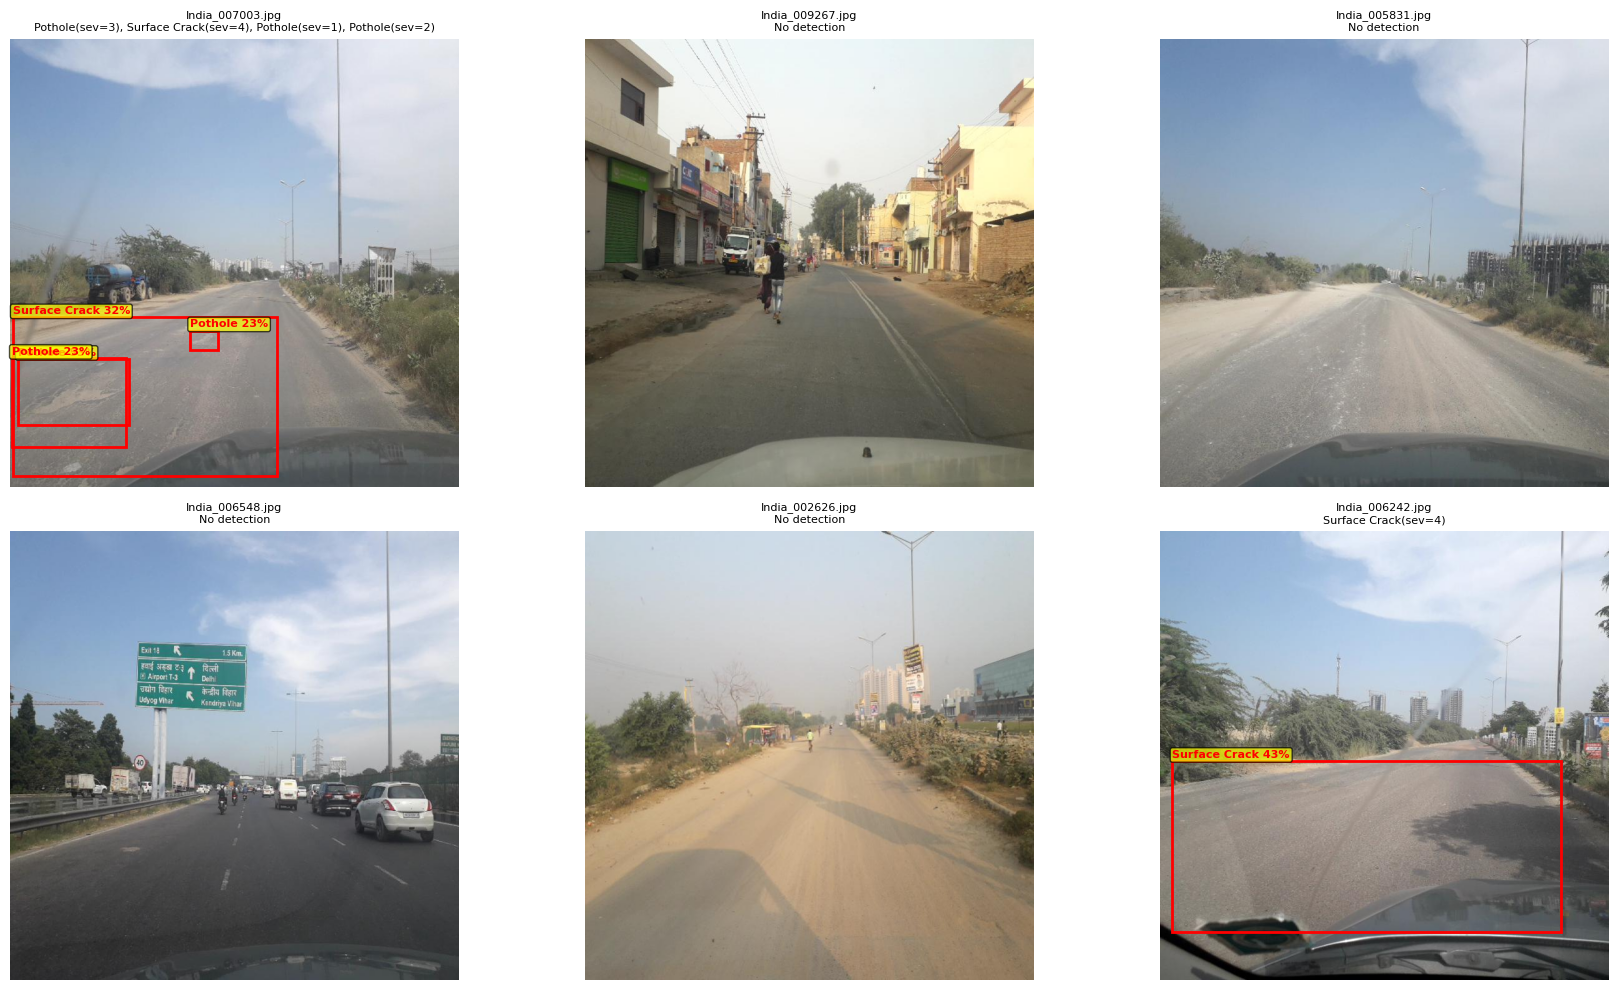

Saved to /content/india_test_results.png


In [11]:
# Test on Indian images specifically + visualize results
import glob, random
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

best_pt = '/content/runs/train/roadwatch_nano/weights/best.pt'
model = YOLO(best_pt)
names = ['Pothole','Surface Crack','Missing Signage','Faded Lane Marking','Damaged Guardrail']

# Get only India images from test set
india_imgs = glob.glob('/content/rdd2022_yolo/test/images/India_*.jpg')
print(f"India test images available: {len(india_imgs)}")

# Pick 6 random India images
random.seed(10)
sample = random.sample(india_imgs, min(6, len(india_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample):
    r = model(img_path, conf=0.20, verbose=False)[0]  # lower conf threshold

    img = Image.open(img_path)
    axes[i].imshow(img)

    title_parts = []
    for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
        x1,y1,x2,y2 = box.cpu().numpy()
        cls_id = int(cls)
        conf_val = float(conf)

        # Draw box
        rect = patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        axes[i].add_patch(rect)
        axes[i].text(x1, y1-5, f"{names[cls_id]} {conf_val:.0%}",
                    color='red', fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

        h, w = r.orig_shape
        ratio = ((x2-x1)*(y2-y1))/(w*h)
        sev = 1 if ratio<0.01 else 2 if ratio<0.03 else 3 if ratio<0.08 else 4 if ratio<0.15 else 5
        if conf_val < 0.45: sev = max(1, sev-1)
        elif conf_val > 0.80: sev = min(5, sev+1)
        title_parts.append(f"{names[cls_id]}(sev={sev})")

    fname = img_path.split('/')[-1]
    axes[i].set_title(fname + '\n' + (', '.join(title_parts) if title_parts else 'No detection'), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/india_test_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved to /content/india_test_results.png")

## Done!

### Place the downloaded file:
```
roadwatch/
  backend/
    ml/
      roadwatch_best.pt   ← PUT IT HERE
```

### Model summary:
- Architecture: YOLOv8-nano (3.2M params, ~6MB)
- Dataset: RDD2022 (remapped to RoadWatch classes)
- Active classes: **Pothole** (class 0) + **Surface Crack** (class 1)
- VRAM for inference: ~800MB → fits in RTX 3050 4GB easily
- Expected mAP50: 0.60–0.75 on Pothole/Crack